In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [ ]:
df=pd.read_csv("mumbai_rentals.csv")
df

,id,date_listed,locality,region,tier,lat,lon,property_type,bedrooms,carpet_area_sqft,...,parking,metro_station,metro_line,metro_distance_min,to_bkc_km,deposit_months,brokerage_months,monthly_rent_inr,annual_rent_inr,rent_per_sqft_carpet_inr
0,R000001,25-02-2026,Goregaon East,Western,mid,19.16098,72.85374,2BHK,2,689,...,1_covered,Azad Nagar,Line 1,60,10.26,10,0,40800,489000,59.2
1,R000002,21-01-2023,Sanpada,Navi Mumbai,mid,19.07703,73.01340,3BHK,3,839,...,2_covered,Nerul Harbour,Harbour,52,15.09,3,1,34600,415000,41.2
2,R000003,03-06-2021,Bandra West,Western,luxury,19.05952,72.81160,3BHK,3,893,...,open,Bandra WR,Western Rail,15,6.25,6,1,145200,1743000,162.7
3,R000004,24-11-2021,Airoli,Navi Mumbai,mid,19.14957,73.01607,1BHK,1,470,...,1_covered,Girgaon,Line 3,361,17.71,6,0,13800,165000,29.3
4,R000005,12-09-2024,Oshiwara,Western,premium,19.15491,72.85538,4BHK,4,1813,...,none,Versova,Line 1,38,9.57,12,1,100100,1201000,55.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22688,R024996,03-11-2023,Kurla East,Central,mid,19.06999,72.89198,2BHK,2,684,...,1_covered,Airport Road,Line 1,46,2.31,12,1,30800,370000,45.0
22689,R024997,28-05-2025,Marine Drive,South Mumbai,luxury,18.93206,72.82227,5BHK_penthouse,5,2473,...,none,Vidhan Bhavan,Line 3,27,16.14,3,1,483700,5805000,195.6
22690,R024998,11-08-2024,Kopar Khairane,Navi Mumbai,mid,19.10135,72.99273,4BHK,4,1320,...,1_covered,Vashi Harbour,Harbour,43,13.36,10,1,40900,491000,31.0
22691,R024999,18-07-2025,Andheri West,Western,premium,19.12233,72.84655,2BHK,2,679,...,open,Andheri,Line 1,34,6.32,6,1,49000,588000,72.2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22693 entries, 0 to 22692
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        22693 non-null  object 
 1   date_listed               22693 non-null  object 
 2   locality                  22693 non-null  object 
 3   region                    22693 non-null  object 
 4   tier                      22693 non-null  object 
 5   lat                       22693 non-null  float64
 6   lon                       22693 non-null  float64
 7   property_type             22693 non-null  object 
 8   bedrooms                  22693 non-null  int64  
 9   carpet_area_sqft          22693 non-null  int64  
 10  built_up_area_sqft        22693 non-null  int64  
 11  carpet_area_m2            22693 non-null  float64
 12  floor                     22693 non-null  int64  
 13  total_floors              22693 non-null  int64  
 14  facing

In [ ]:
df.shape

(22693, 26)

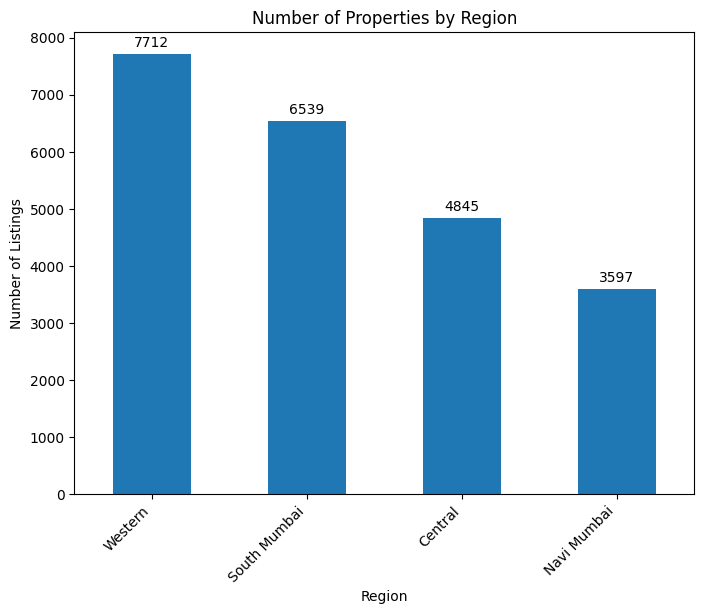

In [ ]:
# 1.Bar Chart- Number of Properties by region

region_counts=df['region'].value_counts()

plt.figure(figsize=(8,6))
ax = region_counts.plot(kind="bar")
region_counts.plot(kind="bar")
plt.title("Number of Properties by Region")
plt.xlabel("Region")
plt.ylabel("Number of Listings")
plt.xticks(rotation=45, ha='right')
ax.bar_label(ax.containers[0], padding=3)
plt.show()

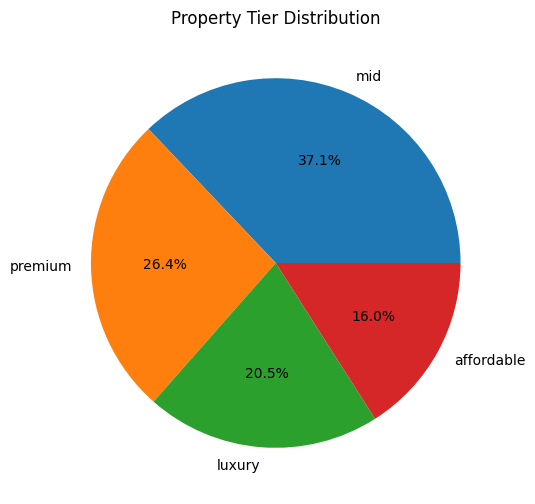

In [ ]:
# 2. Pie Chart-Property Tier Distribution

df["tier"].value_counts().plot(kind="pie",autopct="%1.1f%%",figsize=(6,6))

plt.title("Property Tier Distribution")
plt.ylabel("")
plt.show()

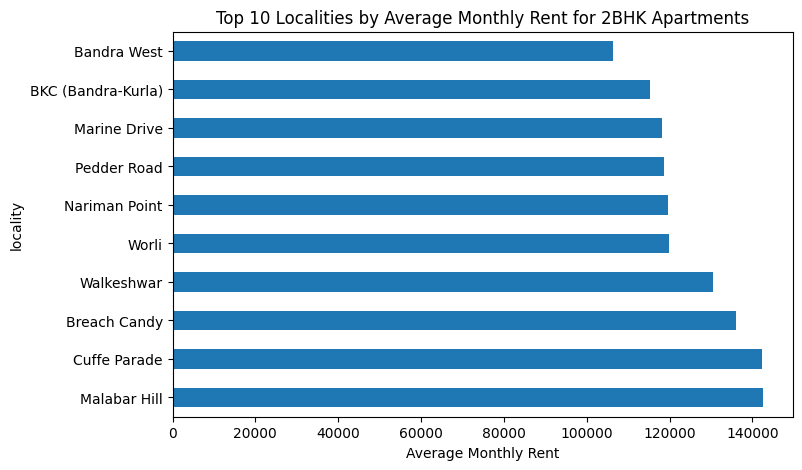

In [ ]:
# 3. Horizontal Bar Chart - Top 10 localities by Average Monthly Rent  for 2BHK Aparttments
df_2bhk = df[df["bedrooms"] == 2]


top_2bhk = (df_2bhk.groupby("locality")["monthly_rent_inr"].mean().sort_values(ascending=False).head(10))

top_2bhk.plot(kind="barh",figsize=(8,5))
plt.title("Top 10 Localities by Average Monthly Rent for 2BHK Apartments")
plt.xlabel("Average Monthly Rent")
plt.show()

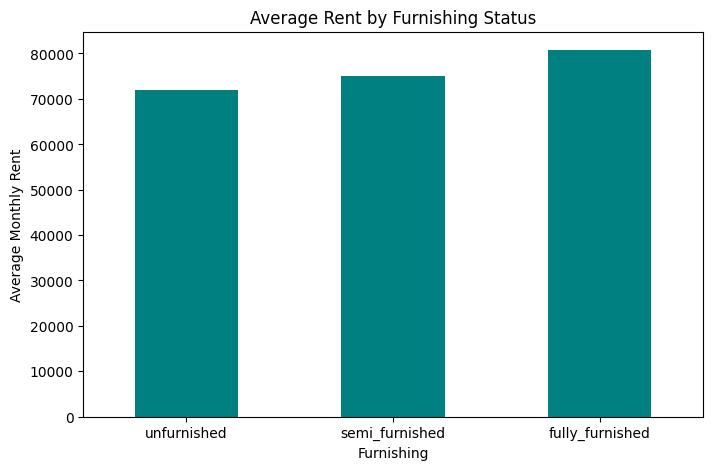

In [ ]:
# 4. Bar chart- Average Rent by Furnishing Status

avg = df.groupby("furnishing")["monthly_rent_inr"].mean().sort_values()


avg.plot(kind="bar", color="teal",figsize=(8,5))

plt.title("Average Rent by Furnishing Status")
plt.xlabel("Furnishing")
plt.ylabel("Average Monthly Rent")
plt.xticks(rotation=0)
plt.show()

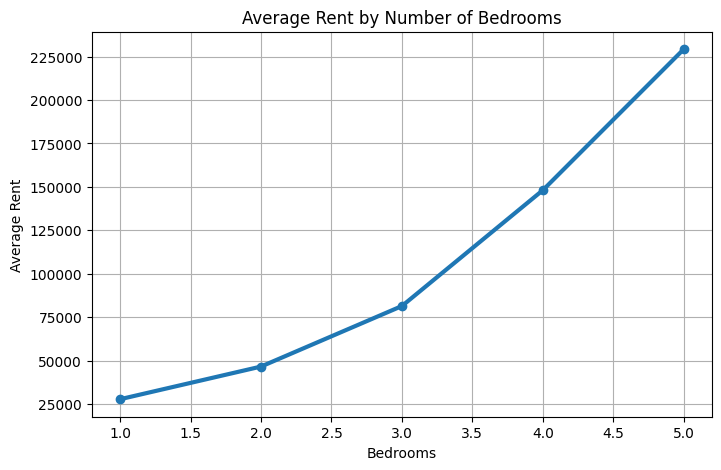

In [ ]:
# 5. Line Chart- Does Metro Connectivity Affect Rent?

avg = df.groupby("bedrooms")["monthly_rent_inr"].mean()

avg.plot(marker="o", linewidth=3,figsize=(8,5))

plt.title("Average Rent by Number of Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Average Rent")
plt.grid(True)
plt.show()

In [ ]:
df2 = df[df["bedrooms"] == 2]

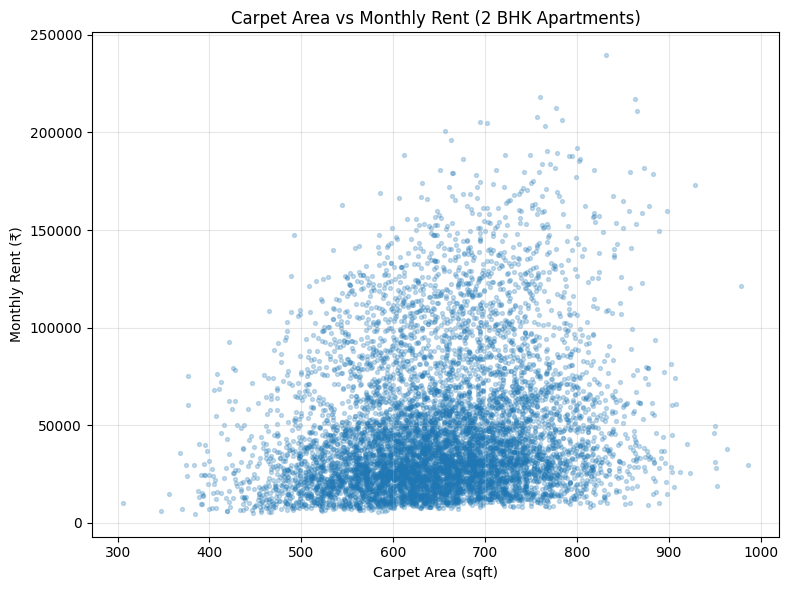

In [ ]:
# Scatter Plot- Carpet Area vs Monthly Rent for 2 BHK Apartments
plt.figure(figsize=(8,6))

plt.scatter(
    df2["carpet_area_sqft"],
    df2["monthly_rent_inr"],
    s=8,
    alpha=0.25
)

plt.title("Carpet Area vs Monthly Rent (2 BHK Apartments)")
plt.xlabel("Carpet Area (sqft)")
plt.ylabel("Monthly Rent (₹)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

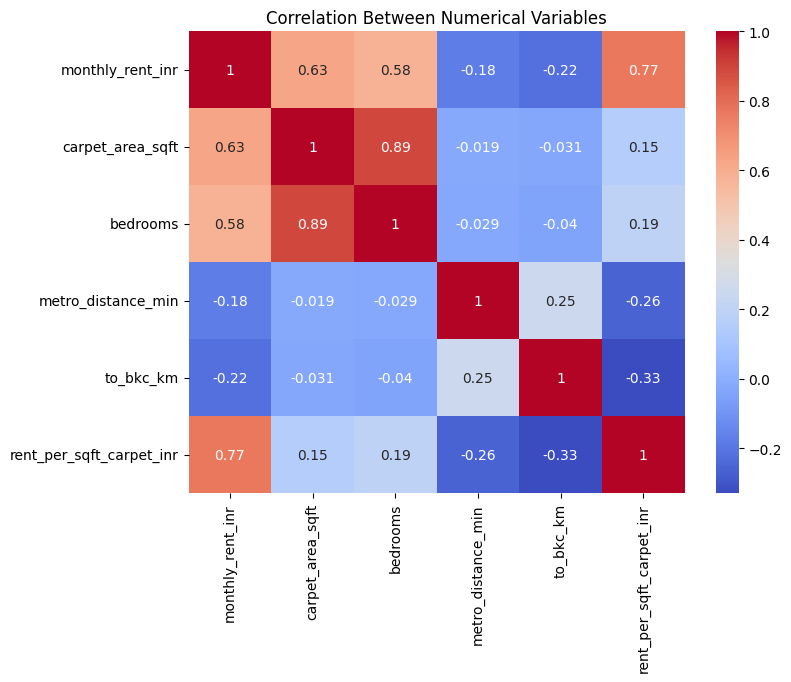

In [ ]:
# 7. Correlation Heatmap

num = [
    "monthly_rent_inr",
    "carpet_area_sqft",
    "bedrooms",
    "metro_distance_min",
    "to_bkc_km",
    "rent_per_sqft_carpet_inr"
]

plt.figure(figsize=(8,6))
sns.heatmap(df[num].corr(),annot=True,cmap="coolwarm")

plt.title("Correlation Between Numerical Variables")
plt.show()

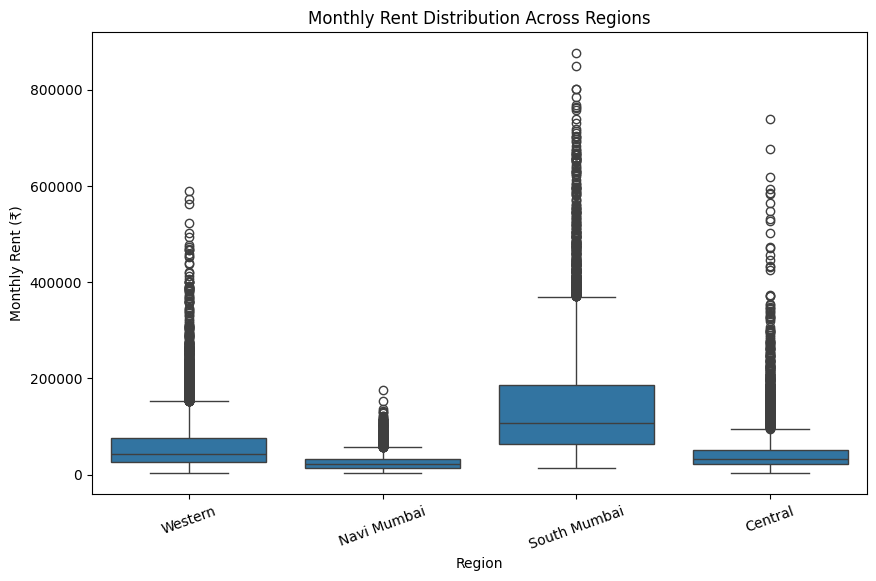

In [ ]:
# 8. Box Plot: Rent Distribution by Region
plt.figure(figsize=(10,6))

sns.boxplot(x="region",y="monthly_rent_inr",data=df)

plt.title("Monthly Rent Distribution Across Regions")
plt.xlabel("Region")
plt.ylabel("Monthly Rent (₹)")
plt.xticks(rotation=20)
plt.show()

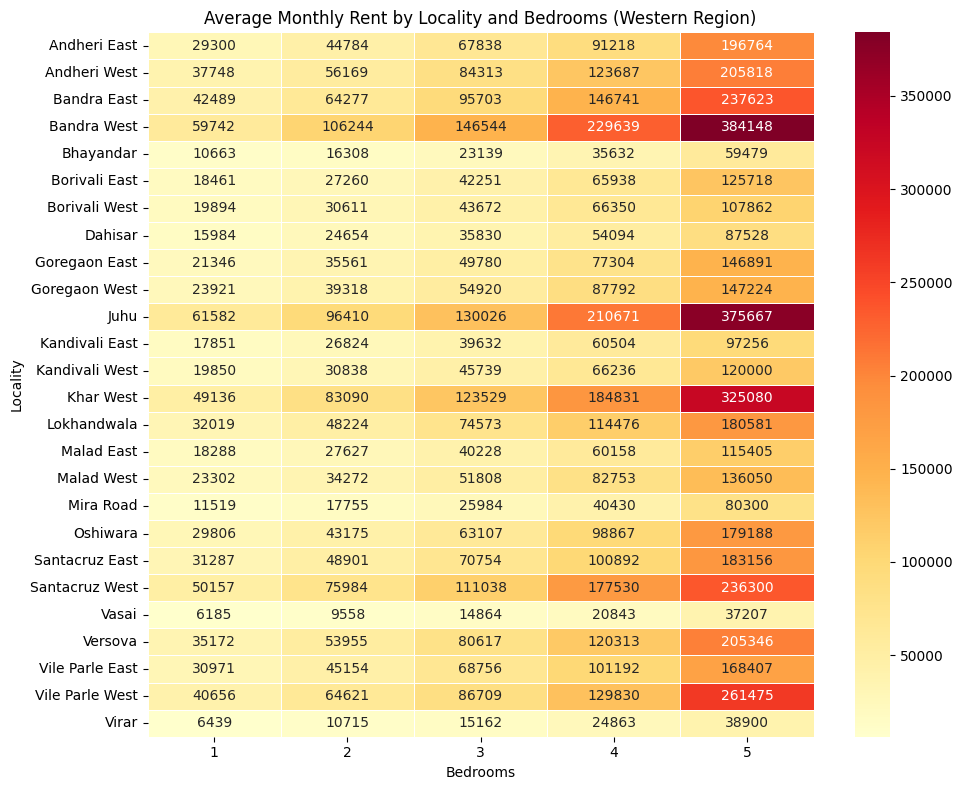

In [ ]:
# 9. HeatMap- Average Monthly Rent by Locality and Number of Bedrooms (Western Region)
western = df[df["region"] == "Western"]

pivot = western.pivot_table(values="monthly_rent_inr",index="locality",columns="bedrooms",aggfunc="mean")

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(pivot,annot=True,fmt=".0f",cmap="YlOrRd",linewidths=0.5)

plt.title("Average Monthly Rent by Locality and Bedrooms (Western Region)")
plt.xlabel("Bedrooms")
plt.ylabel("Locality")
plt.tight_layout()
plt.show()

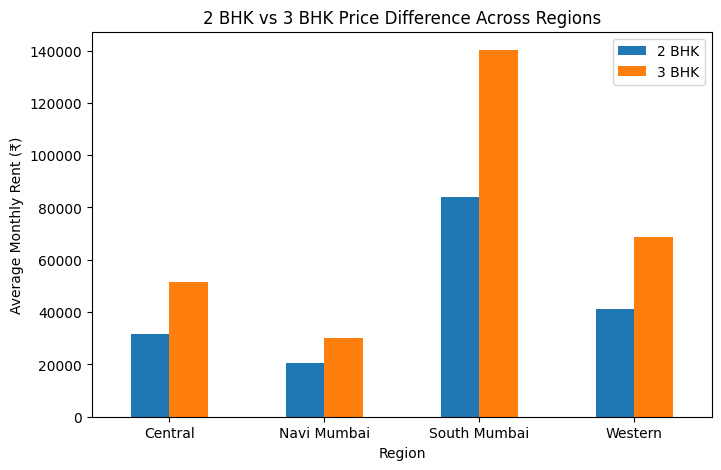

In [ ]:
#10. 2 BHK vs 3 BHK Price Difference

pivot = df.pivot_table(values="monthly_rent_inr",index="region",columns="bedrooms",aggfunc="mean")

pivot[[2,3]].plot(kind="bar",figsize=(8,5))

plt.title("2 BHK vs 3 BHK Price Difference Across Regions")
plt.xlabel("Region")
plt.ylabel("Average Monthly Rent (₹)")
plt.xticks(rotation=0)
plt.legend(["2 BHK","3 BHK"])
plt.show()